# Step 3 — feature distributions by horizon

This checkpoint identifies constant, highly imbalanced, and varying fields independently for days 7, 14, 21, and 30. Exact raw quantiles are saved for numeric fields. Boolean, discrete, and categorical fields receive exact value counts. Numeric histograms use `log1p` only for visual readability; the saved summary retains raw values.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pandas.api.types import is_bool_dtype, is_numeric_dtype

HORIZONS = (7, 14, 21, 30)
project_root = Path.cwd()
if not (project_root / "Dataset").exists():
    project_root = project_root.parent

input_dir = project_root / "Dataset" / "model_horizon_datasets"
output_dir = project_root / "results" / "feature_distributions"
output_dir.mkdir(parents=True, exist_ok=True)
horizon_datasets = {
    horizon: pd.read_csv(input_dir / f"viewcastlk_day_{horizon}.csv", low_memory=False)
    for horizon in HORIZONS
}
print({f"day_{h}": frame.shape for h, frame in horizon_datasets.items()})

{'day_7': (20455, 34), 'day_14': (15599, 34), 'day_21': (15058, 34), 'day_30': (14741, 34)}


In [2]:
topic_feature_columns = sorted(
    column for column in horizon_datasets[7].columns
    if column.startswith("topic_") and column != "topic_missing"
)
topic_labels = {
    column: column.removeprefix("topic_").replace("_", " ").title()
    for column in topic_feature_columns
}
topic_count_rows = []
topic_support_rows = []
for horizon, frame in horizon_datasets.items():
    combinations = frame.apply(
        lambda row: "<MISSING>" if row["topic_missing"] else "|".join(
            topic_labels[column] for column in topic_feature_columns if row[column]
        ),
        axis=1,
    )
    counts = combinations.value_counts()
    for combination, count in counts.items():
        topic_count_rows.append({
            "topic_combination": str(combination),
            "horizon": f"day_{horizon}",
            "rows": int(count),
        })
    for column in [*topic_feature_columns, "topic_missing"]:
        true_rows = int(frame[column].sum())
        topic_support_rows.append({
            "horizon": f"day_{horizon}",
            "topic_feature": column,
            "topic_label": "<MISSING>" if column == "topic_missing" else topic_labels[column],
            "true_rows": true_rows,
            "true_percent": 100 * true_rows / len(frame),
        })

topic_combination_long = pd.DataFrame(topic_count_rows)
topic_combination_inventory = topic_combination_long.pivot(
    index="topic_combination", columns="horizon", values="rows"
).fillna(0).astype(int)
topic_combination_inventory = topic_combination_inventory.reindex(
    columns=[f"day_{horizon}" for horizon in HORIZONS], fill_value=0
).reset_index()
topic_combination_inventory["individual_topic_count"] = topic_combination_inventory["topic_combination"].map(
    lambda value: 0 if value == "<MISSING>" else len(value.split("|"))
)
topic_combination_inventory["horizons_present"] = (
    topic_combination_inventory[[f"day_{horizon}" for horizon in HORIZONS]] > 0
).sum(axis=1)
topic_combination_inventory["total_rows_across_horizons"] = topic_combination_inventory[
    [f"day_{horizon}" for horizon in HORIZONS]
].sum(axis=1)
topic_combination_inventory = topic_combination_inventory.sort_values(
    "topic_combination", key=lambda series: series.str.casefold()
).reset_index(drop=True)
topic_combination_inventory.to_csv(output_dir / "topic_combination_inventory.csv", index=False)
topic_binary_support = pd.DataFrame(topic_support_rows)
topic_binary_support.to_csv(output_dir / "topic_binary_support.csv", index=False)
print(f"Saved {len(topic_combination_inventory) - 1} non-missing topic combinations")


Saved 135 non-missing topic combinations


In [3]:
def feature_kind(series: pd.Series, *, is_target: bool) -> str:
    if is_target:
        return "target"
    if is_bool_dtype(series.dtype):
        return "boolean"
    if is_numeric_dtype(series.dtype):
        return "numeric_discrete" if series.nunique(dropna=True) <= 30 else "numeric_continuous"
    return "categorical"


summary_rows = []
value_count_rows = []

for horizon, source_frame in horizon_datasets.items():
    target_source = f"d{horizon}_views"
    frame = source_frame.rename(columns={target_source: "target_views"})
    for feature in frame.columns:
        series = frame[feature]
        kind = feature_kind(series, is_target=feature == "target_views")
        display_values = series.astype("string").fillna("<MISSING>")
        counts = display_values.value_counts(dropna=False)
        dominant_value = str(counts.index[0])
        dominant_count = int(counts.iloc[0])
        dominant_share = dominant_count / len(series)
        unique_with_missing = int(display_values.nunique(dropna=False))

        if unique_with_missing <= 1:
            status = "CONSTANT"
        elif kind in {"boolean", "categorical", "numeric_discrete"} and dominant_share >= 0.95:
            status = "HIGHLY_IMBALANCED"
        elif kind in {"boolean", "categorical", "numeric_discrete"} and dominant_share >= 0.80:
            status = "IMBALANCED"
        else:
            status = "VARIES"

        numeric = pd.to_numeric(series, errors="coerce") if kind in {"target", "numeric_continuous", "numeric_discrete"} else None
        summary_rows.append({
            "horizon": f"day_{horizon}", "feature": feature, "kind": kind,
            "rows": len(series), "missing_count": int(series.isna().sum()),
            "missing_percent": 100 * series.isna().mean(),
            "unique_including_missing": unique_with_missing,
            "dominant_value": dominant_value, "dominant_count": dominant_count,
            "dominant_percent": 100 * dominant_share, "status": status,
            "minimum": numeric.min() if numeric is not None else np.nan,
            "q25": numeric.quantile(0.25) if numeric is not None else np.nan,
            "median": numeric.median() if numeric is not None else np.nan,
            "q75": numeric.quantile(0.75) if numeric is not None else np.nan,
            "maximum": numeric.max() if numeric is not None else np.nan,
        })

        if kind in {"boolean", "categorical", "numeric_discrete"}:
            for rank, (value, count) in enumerate(counts.items(), start=1):
                value_count_rows.append({
                    "horizon": f"day_{horizon}", "feature": feature, "kind": kind,
                    "value": str(value), "count": int(count),
                    "percent": 100 * int(count) / len(series), "rank": rank,
                })

distribution_summary = pd.DataFrame(summary_rows)
discrete_value_counts = pd.DataFrame(value_count_rows)
distribution_summary.to_csv(output_dir / "feature_distribution_summary.csv", index=False)
discrete_value_counts.to_csv(output_dir / "discrete_value_counts.csv", index=False)
display(distribution_summary.loc[distribution_summary["status"] != "VARIES", [
    "horizon", "feature", "kind", "dominant_value", "dominant_percent", "missing_percent", "status"
]].style.format({"dominant_percent": "{:.1f}%", "missing_percent": "{:.1f}%"}))

,horizon,feature,kind,dominant_value,dominant_percent,missing_percent,status
16,day_7,topic_fashion,boolean,False,99.1%,0.0%,HIGHLY_IMBALANCED
17,day_7,topic_food,boolean,False,97.9%,0.0%,HIGHLY_IMBALANCED
18,day_7,topic_gaming,boolean,False,95.4%,0.0%,HIGHLY_IMBALANCED
19,day_7,topic_health,boolean,False,99.2%,0.0%,HIGHLY_IMBALANCED
20,day_7,topic_hobby,boolean,False,97.8%,0.0%,HIGHLY_IMBALANCED
21,day_7,topic_humour,boolean,False,99.2%,0.0%,HIGHLY_IMBALANCED
22,day_7,topic_knowledge,boolean,False,94.4%,0.0%,IMBALANCED
23,day_7,topic_lifestyle,boolean,False,90.1%,0.0%,IMBALANCED
24,day_7,topic_music,boolean,False,91.1%,0.0%,IMBALANCED
25,day_7,topic_pet,boolean,False,99.2%,0.0%,HIGHLY_IMBALANCED


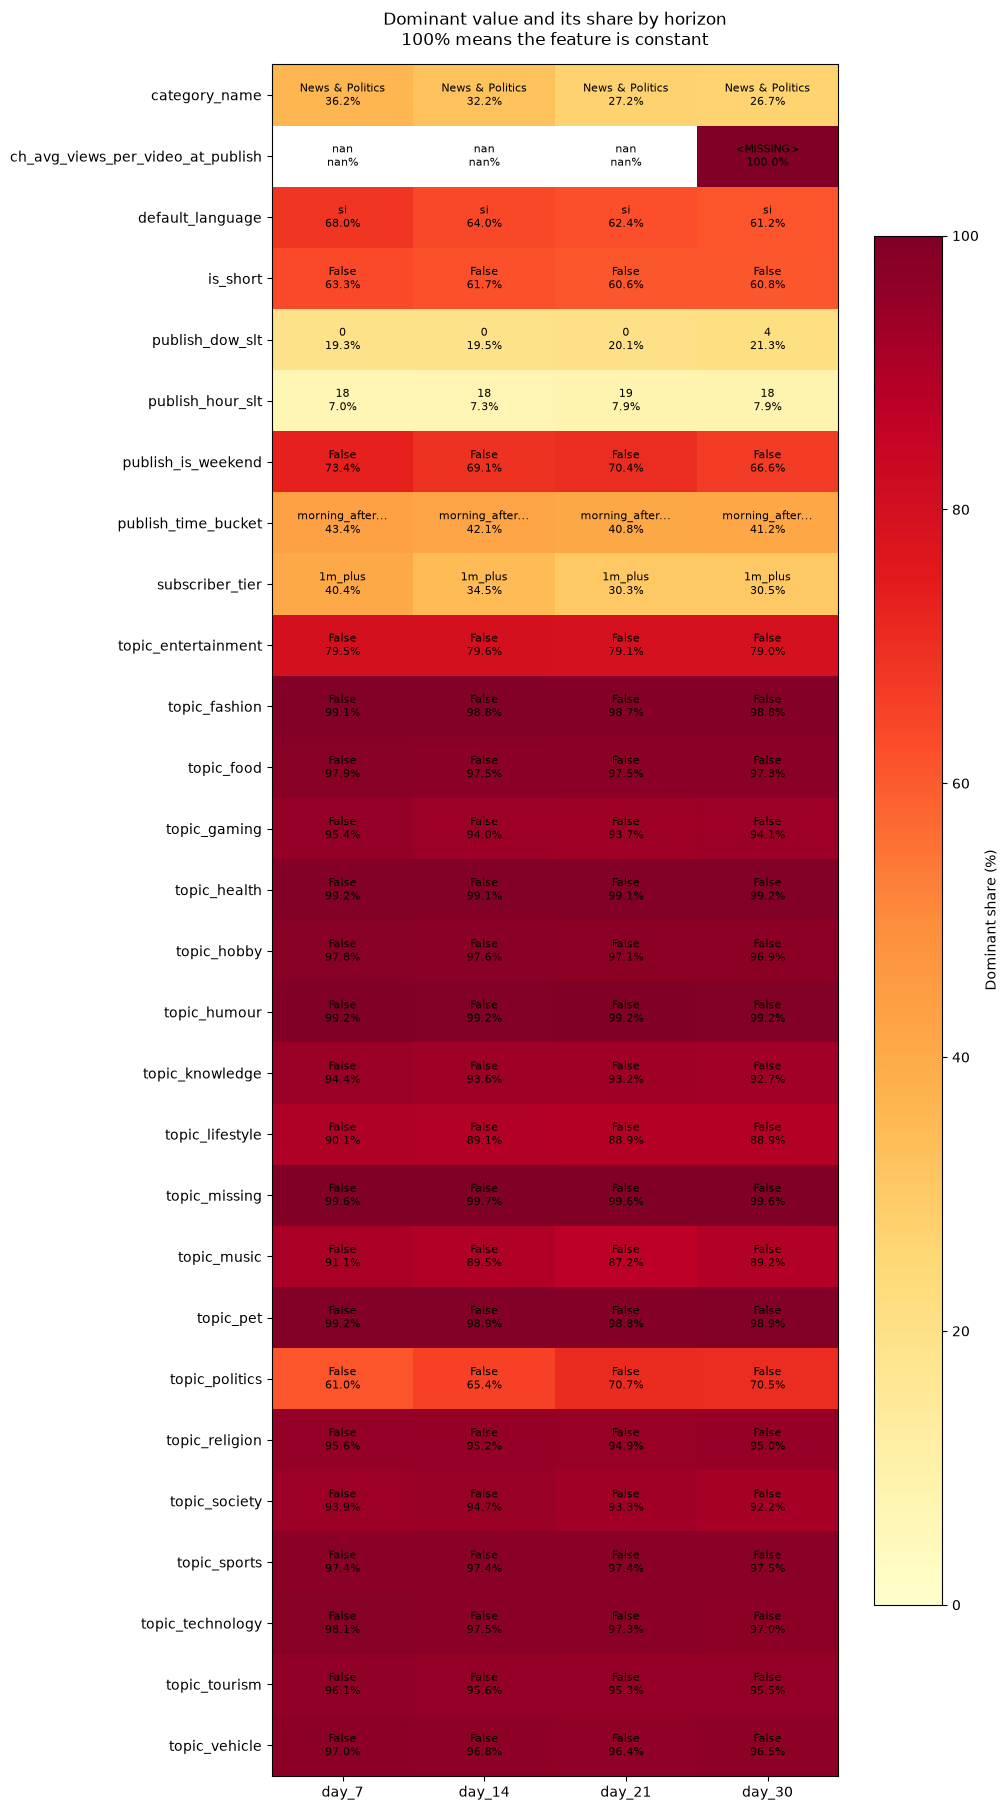

In [4]:
discrete_summary = distribution_summary.loc[
    distribution_summary["kind"].isin(["boolean", "categorical", "numeric_discrete"])
].copy()
dominant_matrix = discrete_summary.pivot(index="feature", columns="horizon", values="dominant_percent")
dominant_values = discrete_summary.pivot(index="feature", columns="horizon", values="dominant_value")
column_order = [f"day_{horizon}" for horizon in HORIZONS]
dominant_matrix = dominant_matrix.reindex(columns=column_order)
dominant_values = dominant_values.reindex(index=dominant_matrix.index, columns=column_order)

figure, axis = plt.subplots(figsize=(10, max(5, 0.65 * len(dominant_matrix))))
image = axis.imshow(dominant_matrix.to_numpy(dtype=float), aspect="auto", cmap="YlOrRd", vmin=0, vmax=100)
axis.set_xticks(range(len(column_order)), column_order)
axis.set_yticks(range(len(dominant_matrix.index)), dominant_matrix.index)
axis.set_title("Dominant value and its share by horizon\n100% means the feature is constant", pad=14)
for row in range(len(dominant_matrix.index)):
    for column in range(len(column_order)):
        value = str(dominant_values.iloc[row, column])
        if len(value) > 16:
            value = value[:13] + "..."
        share = dominant_matrix.iloc[row, column]
        axis.text(column, row, f"{value}\n{share:.1f}%", ha="center", va="center", fontsize=8)
figure.colorbar(image, ax=axis, label="Dominant share (%)", shrink=0.8)
figure.tight_layout()
figure.savefig(output_dir / "dominant_value_share.png", dpi=180, bbox_inches="tight")
plt.show()

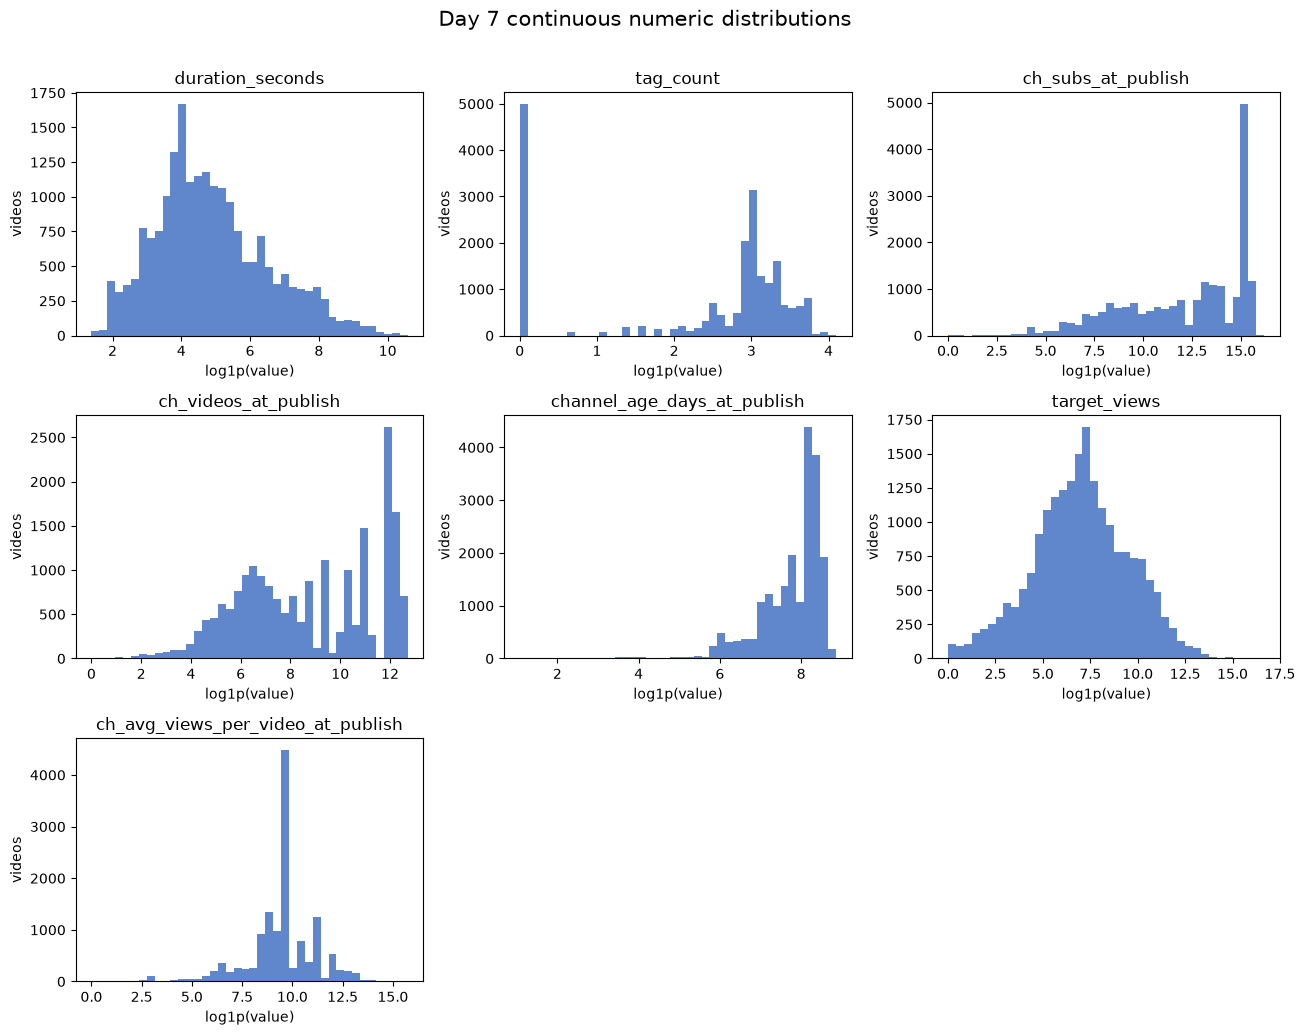

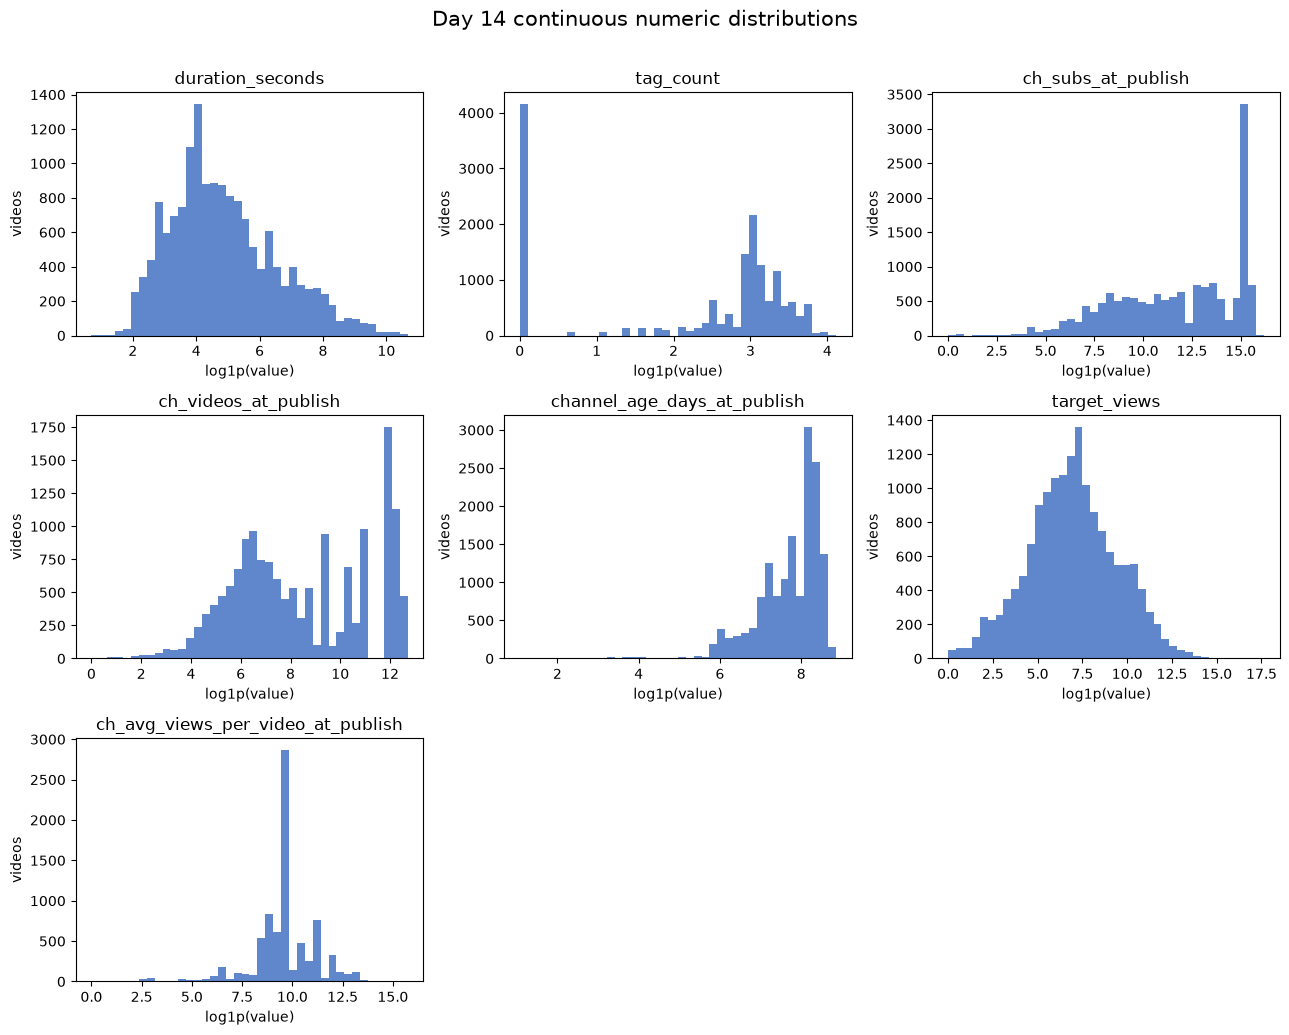

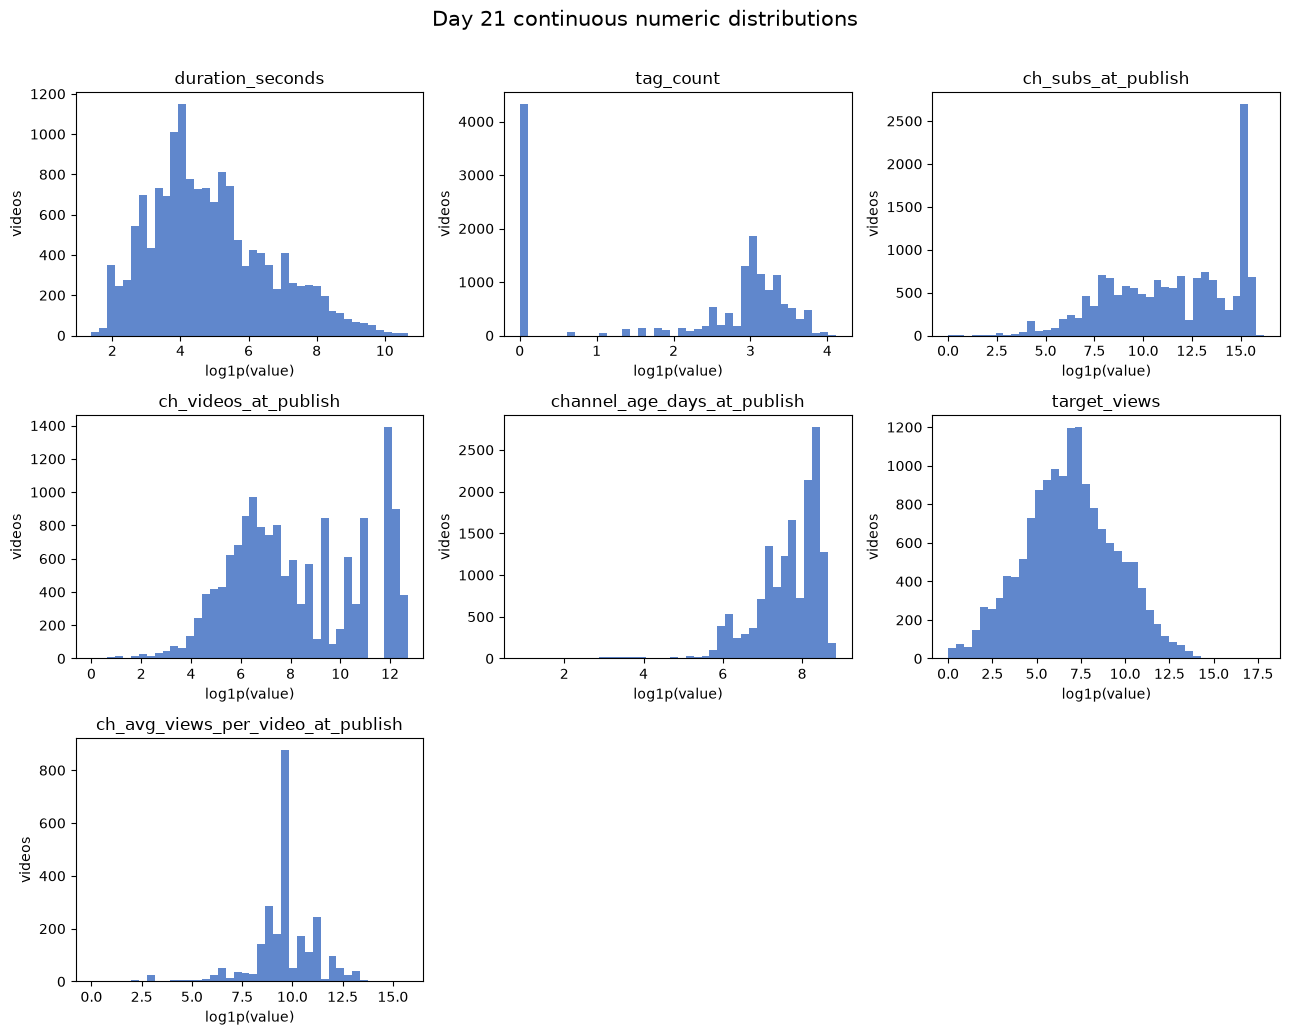

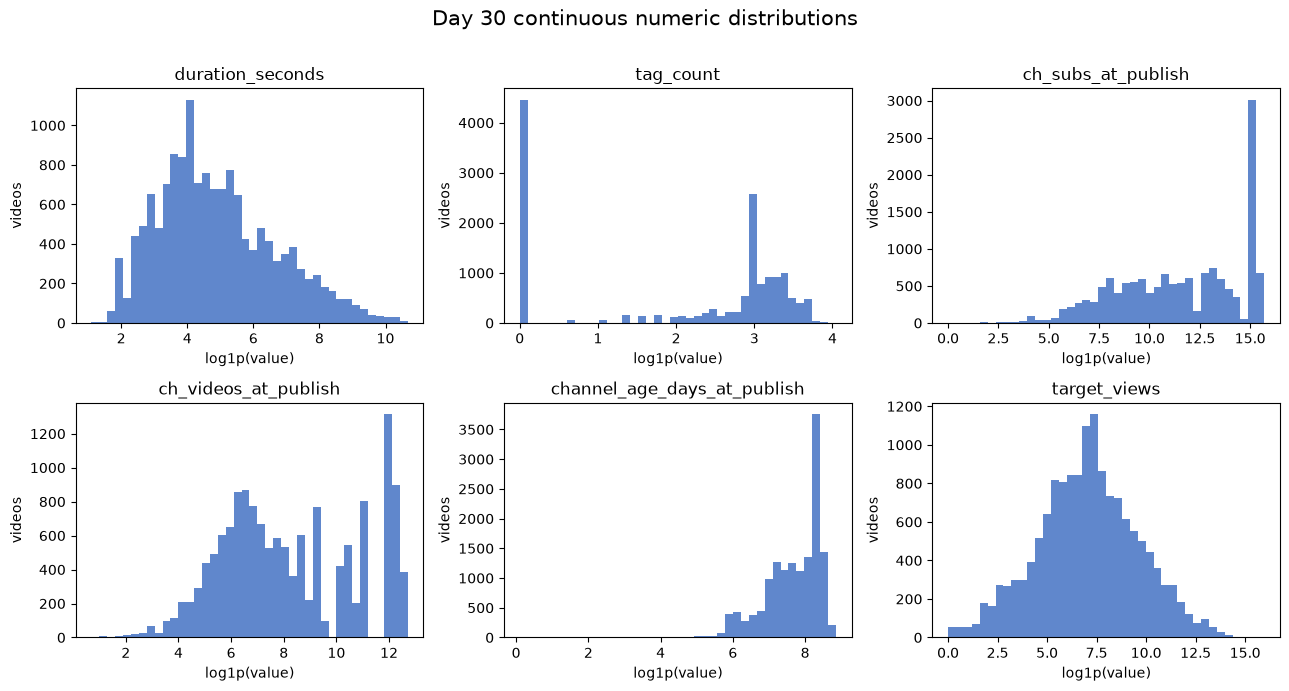

In [5]:
numeric_plot_paths = []
for horizon, source_frame in horizon_datasets.items():
    target_source = f"d{horizon}_views"
    frame = source_frame.rename(columns={target_source: "target_views"})
    numeric_features = distribution_summary.loc[
        (distribution_summary["horizon"] == f"day_{horizon}")
        & distribution_summary["kind"].isin(["numeric_continuous", "target"]),
        "feature",
    ].tolist()
    columns = 3
    rows = int(np.ceil(len(numeric_features) / columns))
    figure, axes = plt.subplots(rows, columns, figsize=(13, 3.4 * rows), squeeze=False)
    for axis, feature in zip(axes.flat, numeric_features):
        values = pd.to_numeric(frame[feature], errors="coerce").dropna()
        plotted = np.log1p(values.clip(lower=0))
        axis.hist(plotted, bins=40, color="#4472C4", alpha=0.85)
        axis.set_title(feature)
        axis.set_xlabel("log1p(value)")
        axis.set_ylabel("videos")
    for axis in axes.flat[len(numeric_features):]:
        axis.set_visible(False)
    figure.suptitle(f"Day {horizon} continuous numeric distributions", y=1.01, fontsize=15)
    figure.tight_layout()
    plot_path = output_dir / f"numeric_distributions_day_{horizon}.png"
    figure.savefig(plot_path, dpi=180, bbox_inches="tight")
    numeric_plot_paths.append(plot_path)
    plt.show()

In [6]:
assert len(distribution_summary) == sum(len(frame.columns) for frame in horizon_datasets.values())
assert set(distribution_summary["horizon"]) == {f"day_{h}" for h in HORIZONS}
assert distribution_summary["dominant_percent"].between(0, 100).all()
assert distribution_summary["missing_percent"].between(0, 100).all()
assert set(distribution_summary["status"]).issubset({"CONSTANT", "HIGHLY_IMBALANCED", "IMBALANCED", "VARIES"})
assert (output_dir / "dominant_value_share.png").exists()
assert (output_dir / "topic_combination_inventory.csv").exists()
assert (output_dir / "topic_binary_support.csv").exists()
assert topic_combination_inventory["topic_combination"].is_unique
for horizon in HORIZONS:
    assert topic_combination_inventory[f"day_{horizon}"].sum() == len(horizon_datasets[horizon])
    frame = horizon_datasets[horizon]
    assert "topic_categories" not in frame.columns
    assert frame[[*topic_feature_columns, "topic_missing"]].dtypes.map(lambda dtype: dtype == bool).all()
    assert (frame[[*topic_feature_columns, "topic_missing"]].sum(axis=1) >= 1).all()
assert all(path.exists() for path in numeric_plot_paths)
for horizon in HORIZONS:
    expected = set(horizon_datasets[horizon].columns) - {f"d{horizon}_views"} | {"target_views"}
    actual = set(distribution_summary.loc[distribution_summary["horizon"] == f"day_{horizon}", "feature"])
    assert actual == expected
print(f"PASS: distributions checked for {len(distribution_summary)} horizon-variable combinations")

PASS: distributions checked for 136 horizon-variable combinations
